In [83]:
"""
Need a way to know where stop signs are and stop at them.
Example Algorithm below
"""

from dataclasses import dataclass
from typing import List, Union
from math import pi, cos, sin

class Point:
    x: float
    y: float
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __add__(self, other: Union["Point", float, int]):
        if isinstance(other, Point):
            return Point(self.x + other.x, self.y + other.y)
        elif isinstance(other, float) or isinstance(other, int):
            return Point(self.x + other, self.y + other)
        else:
            raise ValueError(f'Cannot add Point and {type(other)}')
    
    def __sub__(self, other: Union["Point", float, int]):
        if isinstance(other, Point):
            return Point(self.x - other.x, self.y - other.y)
        elif isinstance(other, float) or isinstance(other, int):
            return Point(self.x - other, self.y - other)
        else:
            raise ValueError(f'Cannot substract Point and {type(other)}')
    
    def cross(self, other: "Point") -> float:
        return self.x * other.y - self.y * other.x
    
    def dot(self, other: "Point") -> float:
        return self.x * other.x + self.y * other.y
    
    def __mul__(self, other: float):
        return Point(self.x * other, self.y * other)
    
    def __rmul__(self, other: float):
        return Point(self.x * other, self.y * other)

class Lane:
    left: List[Point]
    right: List[Point]
    def __init__(self):
        self.left = []
        self.right = []
    
@dataclass
class Feature:
    position: Point
    label: str

    def __init__(self, x: float, y: float):
        super().__init__(self)
        self.label = "Unknown"
        self.position = Point(x, y)

In [84]:

def generate_circular_path(
    radius: float, num_points: int, path_width: float, center=(0, 0)
) -> Lane:
    cx, cy = center
    path = Lane()

    for i in range(num_points):
        angle = 2 * pi * i / num_points

        x = cx + radius * cos(angle)
        y = cy + radius * sin(angle)

        x_offset = path_width * cos(angle)
        y_offset = path_width * sin(angle)

        path.left.append(Point(x - x_offset, y - y_offset))
        path.right.append(Point(x + x_offset, y + y_offset))

    return path

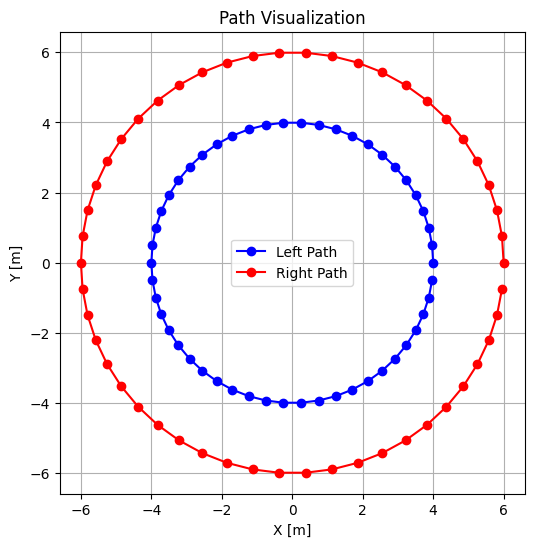

In [85]:
import matplotlib.pyplot as plt

def plot_path(path: Lane):
    # extract coords
    left_x = [p.x for p in path.left]
    left_y = [p.y for p in path.left]
    right_x = [p.x for p in path.right]
    right_y = [p.y for p in path.right]

    plt.figure(figsize=(6,6))
    plt.plot(left_x, left_y, 'b-o', label="Left Path")    # Blue line with points
    plt.plot(right_x, right_y, 'r-o', label="Right Path") # Red line with points
    plt.axis('equal')  # Keep aspect ratio square
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.title("Path Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_path(generate_circular_path(5, 50, 1))

In [86]:
from random import random

@dataclass
class StopSign:
    location: Point

    @staticmethod
    def random(d) -> "StopSign":
        """ 
        Creates a random stop sign in the square bounded by (-d, -d) and (d, d)
        """
        ss = StopSign(location=Point(
            x = random() * 2 * d - d,
            y = random() * 2 * d - d
        ))
        return ss 

[ 0.37511191 -0.17750375] [ 0.37511191 -0.17750375]


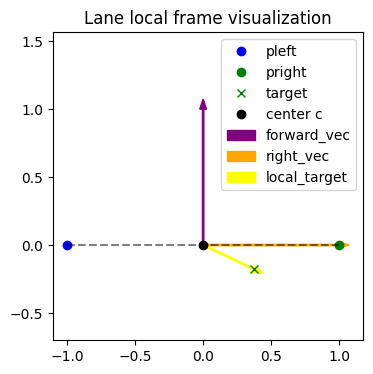

[-0.72508837 -0.35548403] [-0.72508837 -0.35548403]


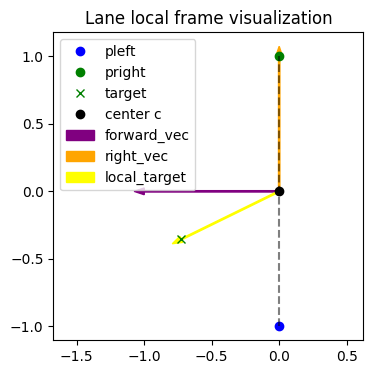

[-0.17678168  1.51049646] [-0.17678168  1.51049646]


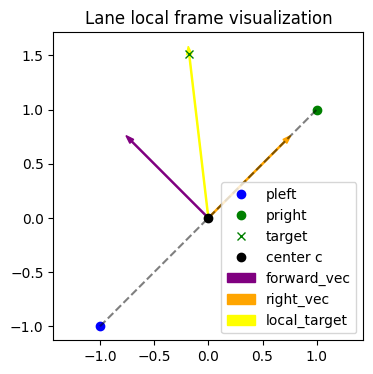

[ 1.45007245 -0.71362794] [ 1.45007245 -0.71362794]


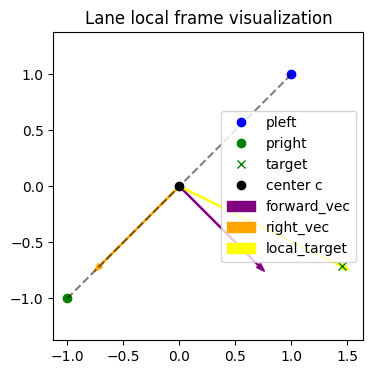

In [87]:
from enum import Enum
from math import sqrt

import numpy as np

class SIDES(Enum):
    LEFT = 0
    RIGHT = 1
    NULL = 2
    INSIDE = 3

def dist(p1: Point, p2: Point):
    return sqrt((p2.x - p1.x) ** 2 + (p2.y - p1.y) ** 2)

def find_closest_point(point: Point, lane: Lane):
    """
    Finds the closest waypoint to `point` in `lane`.
    If all distances are identical it will return the first waypoint in the left boundary of the lane and the side it's on.
    If there are no points in the lane it will return None, None.
    """
    min_point: Point = None
    min_dist: float = None
    side = SIDES.NULL

    # find closest waypoint
    for p in lane.left:
        d = dist(point, p)
        if min_point is None and min_dist is None:
            side = SIDES.LEFT
            min_point = p
            min_dist = d
            continue 

        if d < min_dist:
            side = SIDES.LEFT
            min_point = p
            min_dist = d

    for p in lane.left + lane.right:
        d = dist(point, p)
        if min_point is None and min_dist is None:
            side = SIDES.RIGHT
            min_point = p
            min_dist = d
            continue 

        if d < min_dist:
            side = SIDES.RIGHT
            min_point = p
            min_dist = d

    return (min_point, side)

def find_opposite_point(point: Point, side: SIDES, lane: Lane):
    """ 
    Finds the opposite point in lane.
    If right is provided it will provide the left and vice versa.
    """
    idx = -1 # where the point is in one of the lane arrays

    # find it in the left first
    if side == SIDES.LEFT:
        if point in lane.left:
            idx = lane.left.index(point)
            return lane.right[idx]
    elif side == SIDES.RIGHT:
        if point in lane.right:
            idx = lane.right.index(point)
            return lane.left[idx]
    else:
        return None, None

def normalize(point: Point):
    d = dist(point, Point(0, 0))
    return Point(point.x / d, point.y / d)

def determine_point_orientation(target: Point, lane: Lane):
    """ 
    Determines if point is to the left, right, or inside of lane.
    """
    # Find the two boundary points around target
    closest_point, side = find_closest_point(target, lane)

    if side == SIDES.LEFT:
        pleft = closest_point
        pright = find_opposite_point(closest_point, side, lane)
    elif side == SIDES.RIGHT:
        pright = closest_point
        pleft = find_opposite_point(closest_point, side, lane)
    else:
        raise ValueError("Point not found in lane")
    
    return solve_3_point(pleft, pright, target)[0]

def solve_3_point(pleft: Point, pright: Point, target: Point):
    # Build coordinate system around path forward vector
    c: Point = 0.5 * (pleft + pright)
    right_vec = normalize(pright - c) 
    
    forward_vec = Point(-right_vec.y, right_vec.x)

    # Transform target to new coord system
    p = target - c
    local_x = p.dot(right_vec)
    local_y = p.dot(forward_vec)

    # Compute boundary extents
    pleft_local_x = (pleft - c).dot(right_vec)
    pright_local_x = (pright - c).dot(right_vec)


    # Classify
    if local_x < pleft_local_x:
        dir = SIDES.LEFT 
    elif local_x > pright_local_x:
        dir = SIDES.RIGHT 
    else:
        dir = SIDES.INSIDE

    return dir, forward_vec, right_vec, local_x, local_y

def plot_3_point(pl: Point, pr: Point, target: Point):
    # Midpoint
    c: Point = 0.5 * (pl + pr)

    # Solve local frame
    dir, forward_vec, right_vec, local_x, local_y = solve_3_point(pl, pr, target)

    # convert to numpy arrays to work with matplotlib
    def to_numpy(p: Point):
        return np.array([p.x, p.y])
    
    c = to_numpy(c)
    pl = to_numpy(pl)
    pr = to_numpy(pr)
    target = to_numpy(target)
    forward_vec = to_numpy(forward_vec)
    right_vec = to_numpy(right_vec)

    # determine color
    target_color = ''
    if dir == SIDES.LEFT:
        target_color = 'blue'
    elif dir == SIDES.RIGHT:
        target_color = 'red'
    elif dir == SIDES.INSIDE:
        target_color = 'green'
    else:
        raise ValueError('WTH boy')
    
    # plot
    plt.figure(figsize=(4, 4))
    plt.axis('equal')

    # plot points
    plt.plot(pl[0], pl[1], 'bo', label='pleft')
    plt.plot(pr[0], pr[1], 'go', label='pright')
    plt.plot(target[0], target[1], 'x', label='target', color=target_color)
    plt.plot(c[0], c[1], 'ko', label='center c')

    # Plot arrows for forward and right vectors (from c)
    plt.arrow(c[0], c[1], forward_vec[0], forward_vec[1],
              color='purple', width=0.01, head_width=0.05, label='forward_vec')
    plt.arrow(c[0], c[1], right_vec[0], right_vec[1],
              color='orange', width=0.01, head_width=0.05, label='right_vec')
    
    # plot the local vector too
    local_vec = (local_x * right_vec) + (local_y * forward_vec)
    print(target, local_vec) # sanity check
    plt.arrow(c[0], c[1], local_vec[0], local_vec[1],
              color='yellow', width=0.01, head_width=0.05, label='local_target')
    
    # Draw line connecting pleft → pright for reference
    plt.plot([pl[0], pr[0]], [pl[1], pr[1]], 'k--', alpha=0.5)

    plt.legend()
    plt.title("Lane local frame visualization")
    plt.show()

# draw perfectly straight
plot_3_point(Point(-1, 0), Point(1, 0), StopSign.random(2).location)

# draw perfectly vertical
plot_3_point(Point(0, -1), Point(0, 1), StopSign.random(2).location)

# draw diagonal
plot_3_point(Point(-1, -1), Point(1, 1), StopSign.random(2).location)

# draw other diagonal
plot_3_point(Point(1, 1), Point(-1, -1), StopSign.random(2).location)


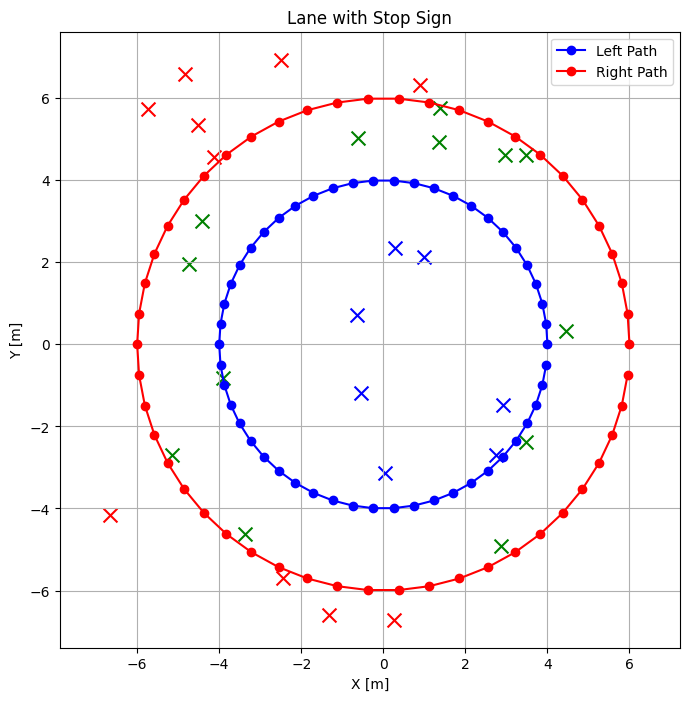

In [88]:
def plot_lane_with_signs(lane: Lane, signs: list[StopSign]):
    # Extract lane coordinates
    left_x = [p.x for p in lane.left]
    left_y = [p.y for p in lane.left]
    right_x = [p.x for p in lane.right]
    right_y = [p.y for p in lane.right]

    plt.figure(figsize=(8, 8))
    # Plot lane
    plt.plot(left_x, left_y, 'b-o', label="Left Path")
    plt.plot(right_x, right_y, 'r-o', label="Right Path")
    
    # Plot marker
    for sign in signs:
        side = determine_point_orientation(sign.location, lane)
        color = ''
        if side == SIDES.LEFT:
            color = 'blue'
        elif side == SIDES.RIGHT:
            color = 'red'
        elif side == SIDES.INSIDE:
            color = 'green'
        else:
            raise ValueError('WTH boy')

        plt.scatter(sign.location.x, sign.location.y, color=color, marker='x', s=100)
    
    plt.axis('equal')  # equal aspect ratio
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.title("Lane with Stop Sign")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_lane_with_signs(generate_circular_path(5, 50, 1), [StopSign.random(7) for _ in range(30)])